In [1]:
import glob
import os
import io
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import polars.selectors as cs
import sklearn.metrics as metrics
import scipy.stats as st

from hta.trace_analysis import TraceAnalysis
from plot_utils import plot_xy, plot_bar

In [2]:
v100_power_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/power_logs/*-power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/power_logs/(.*)-power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
    .with_columns(
        pl.when(pl.col("benchmark").str.contains("-train"))
        .then(pl.col("benchmark"))
        .otherwise(pl.col("benchmark") + "-inference")
        .alias("benchmark")
    )
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()
        ) * 1e6,
        time_us = (pl.col("timestamp_ns").max() - pl.col("timestamp_ns").min()) / 10000 / 1000
    )
    .rename({"power_w": "v100_measured_power_W", "time_us": "v100_measured_total_time_us"})
)

In [3]:
a30_power_df = (
    pl.scan_csv(
        "/proj/threadtune-PG0/amir/A30/*/power.0.csv", 
        include_file_paths="path",
    )
    .with_columns(
        pl.col("path").str.extract(r"/proj/threadtune-PG0/amir/A30/(.*)/power.0.csv")
        .alias("benchmark"),
    )
    .drop("path")
    .collect()
    .group_by("benchmark")
    .agg(
        power_w=(
            pl.col("total_energy_millijoules").max() - pl.col("total_energy_millijoules").min()
        ) / (
            pl.col("cpu_ts").max() - pl.col("cpu_ts").min()
        ) * 1e6,
        time_us = (pl.col("cpu_ts").max() - pl.col("cpu_ts").min()) / 10000 / 1000
    )
    .rename({"power_w": "a30_measured_power_W", "time_us": "a30_measured_total_time_us"})
)

In [4]:
results = []

for trace_dir in glob.glob("/proj/threadtune-PG0/amir/kineto_traces/*"):
    benchmark_name = os.path.basename(trace_dir)
    json_path = os.path.join(trace_dir, "device.0.json")

    kineto_df = (
        pl.read_json(json_path)
        .select(pl.col("traceEvents").explode().struct.unnest())
    )

    total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
    total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

    if total_trace_dur is None: total_trace_dur = 0
    if total_kernel_dur is None: total_kernel_dur = 0
    
    idle_time_us = total_trace_dur - total_kernel_dur
   
    results.append({
        "benchmark": benchmark_name,
        "v100_measured_idle_time_us": idle_time_us
    })

v100_idle_df = pl.DataFrame(results)

In [5]:
results = []

for trace_dir in glob.glob("/proj/threadtune-PG0/amir/A30/*"):
    benchmark_name = os.path.basename(trace_dir)
    json_path = os.path.join(trace_dir, "device.0.json")

    kineto_df = (
        pl.read_json(json_path)
        .select(pl.col("traceEvents").explode().struct.unnest())
    )

    total_trace_dur = kineto_df.filter(pl.col("cat") == "Trace").select(pl.col("dur")).sum().item()
    total_kernel_dur = kineto_df.filter(pl.col("cat") == "kernel").select(pl.col("dur")).sum().item()

    if total_trace_dur is None: total_trace_dur = 0
    if total_kernel_dur is None: total_kernel_dur = 0
    
    idle_time_us = total_trace_dur - total_kernel_dur
   
    results.append({
        "benchmark": benchmark_name,
        "a30_measured_idle_time_us": idle_time_us
    })

a30_idle_df = pl.DataFrame(results)

In [6]:
dfs = []

for d in [f for f in os.scandir("/proj/threadtune-PG0/amir/kineto_traces/") if f.is_dir()]:
    analyzer = TraceAnalysis({0: "device.0.json"}, d.path)
    sym = analyzer.t.symbol_table.get_sym_table()
    
    dfs.append(pl.concat([
        pl.from_pandas(analyzer.t.get_trace(r)[analyzer.t.get_trace(r)["stream"] != -1][["name", "dur"]])
        for r in analyzer.t.traces
    ]).join(
        pl.from_dict({"name": list(range(len(sym))), "s_name": sym}), on="name"
    ).filter(
        ~pl.col("s_name").str.starts_with("nccl") & 
        ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
    ).select(
        pl.lit(d.name).alias("benchmark"),
        pl.col("dur").sum().alias("v100_measured_kernel_time_sum_us")
    ))

v100_time_df = pl.concat(dfs)

Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json time = 0.21 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json backend=json in 0.45 seconds; current PID:32917
Overall parsing of /proj/threadtune-PG0/amir/kineto_traces/deit-train/device.0.json in 0.50 seconds; current PID:32917
leaving parse_multiple_ranks duration=0.51 seconds
leaving parse_traces duration=0.52 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-inference/device.0.json time = 0.15 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/kineto_traces/gpt2-

In [7]:
dfs = []

for d in [f for f in os.scandir("/proj/threadtune-PG0/amir/A30/") if f.is_dir()]:
    analyzer = TraceAnalysis({0: "device.0.json"}, d.path)
    sym = analyzer.t.symbol_table.get_sym_table()
    
    dfs.append(pl.concat([
        pl.from_pandas(analyzer.t.get_trace(r)[analyzer.t.get_trace(r)["stream"] != -1][["name", "dur"]])
        for r in analyzer.t.traces
    ]).join(
        pl.from_dict({"name": list(range(len(sym))), "s_name": sym}), on="name"
    ).filter(
        ~pl.col("s_name").str.starts_with("nccl") & 
        ~pl.col("s_name").is_in(["Stream Sync", "Memcpy DtoD (Device -> Device)", "Memcpy HtoD (Pageable -> Device)", "Memcpy DtoH (Device -> Pinned)"])
    ).select(
        pl.lit(d.name).alias("benchmark"),
        pl.col("dur").sum().alias("a30_measured_kernel_time_sum_us")
    ))

a30_time_df = pl.concat(dfs)

Parsed /proj/threadtune-PG0/amir/A30/gpt2-inference/device.0.json time = 0.12 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/A30/gpt2-inference/device.0.json backend=json in 0.20 seconds; current PID:32917
Overall parsing of /proj/threadtune-PG0/amir/A30/gpt2-inference/device.0.json in 0.23 seconds; current PID:32917
leaving parse_multiple_ranks duration=0.23 seconds
leaving parse_traces duration=0.23 seconds
There is only one iteration in the trace. The analysis result may not be accurate.
Parsed /proj/threadtune-PG0/amir/A30/gemma-inference/device.0.json time = 0.02 seconds 
Rounding down ns resolution events due to issue with events overlapping. ts dtype = float64, dur dtype = float64.Please see https://github.com/pytorch/pytorch/pull/122425
Parsed /proj/threadtune-PG0/amir/A30/gemma-inference/device.0.json backend=json

In [8]:
final_df = (
    v100_power_df
    .join(v100_idle_df, on="benchmark")
    .join(v100_time_df, on="benchmark")
    .join(a30_power_df, on="benchmark")
    .join(a30_idle_df, on="benchmark")
    .join(a30_time_df, on="benchmark")
)
final_df

benchmark,v100_measured_power_W,v100_measured_total_time_us,v100_measured_idle_time_us,v100_measured_kernel_time_sum_us,a30_measured_power_W,a30_measured_total_time_us,a30_measured_idle_time_us,a30_measured_kernel_time_sum_us
str,f64,f64,f64,f64,f64,f64,f64,f64
"""gpt2-inference""",38.570944,22697.103064,461579.941,2785.0,48.7633,13635.295469,318860.936,2944.0
"""gemma-inference""",107.656783,20228.55822,492388.531,10994.0,99.729634,18127.500612,350016.833,12395.0
"""resnet50-train""",70.123221,41214.817838,690036.105,10838.0,62.924426,27422.327346,600592.553,11527.0
"""deit-train""",68.242799,45746.64186,653582.668,11432.0,63.502272,30475.889294,537626.454,13555.0
"""bloom-inference""",74.344924,15222.401692,553572.69,4506.0,67.436255,11347.907731,370629.243,4855.0
…,…,…,…,…,…,…,…,…
"""gpt2-train""",89.669436,52817.232234,557731.427,22947.0,79.370023,50795.971321,436709.734,27445.0
"""bert-inference""",59.101363,10755.061665,312991.064,1601.0,50.166719,6123.898542,277934.729,2157.0
"""deit-inference""",54.731851,41999.117103,319870.91,2906.0,65.169345,4243.220473,209413.373,3516.0


Text(0, 0.5, 'Modeled Idle Time (us)')

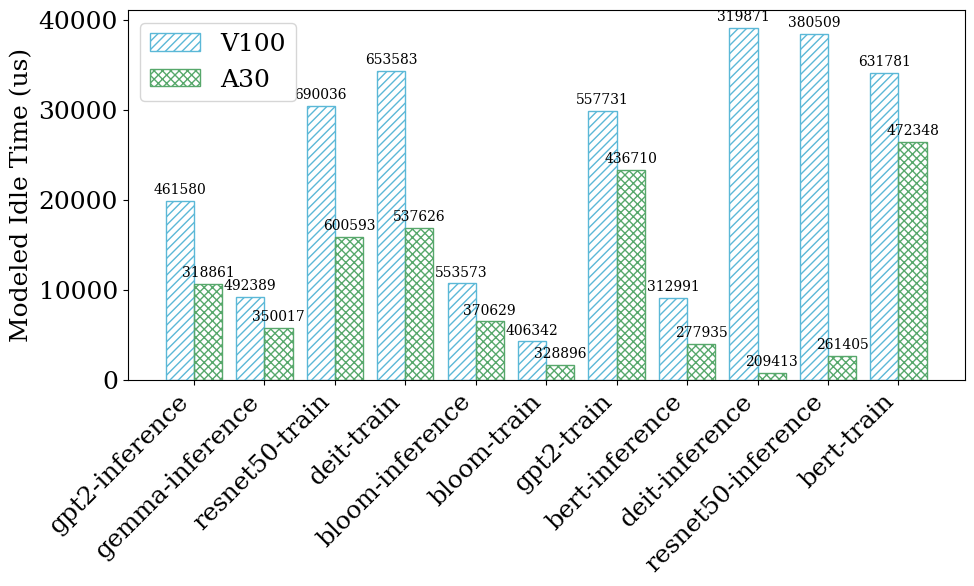

In [11]:
v100_data = final_df.select(
    pl.col("benchmark"),
    pl.lit("V100").alias("device"),
    (pl.col("v100_measured_total_time_us") - pl.col("v100_measured_kernel_time_sum_us")).alias("modeled_idle_us"),
    pl.col("v100_measured_idle_time_us").alias("measured_idle_us")
)

a30_data = final_df.select(
    pl.col("benchmark"),
    pl.lit("A30").alias("device"),
    (pl.col("a30_measured_total_time_us") - pl.col("a30_measured_kernel_time_sum_us")).alias("modeled_idle_us"),
    pl.col("a30_measured_idle_time_us").alias("measured_idle_us")
)

plot_df = pl.concat([v100_data, a30_data])

ax = plot_bar(
    plot_df, 
    x="benchmark", 
    y="modeled_idle_us", 
    hue="device", 
    ylabel="measured_idle_us", 
    ndigits=0
)

ax.set_ylabel("Modeled Idle Time (us)")

Text(0, 0.5, 'Idle Percentage (%)')

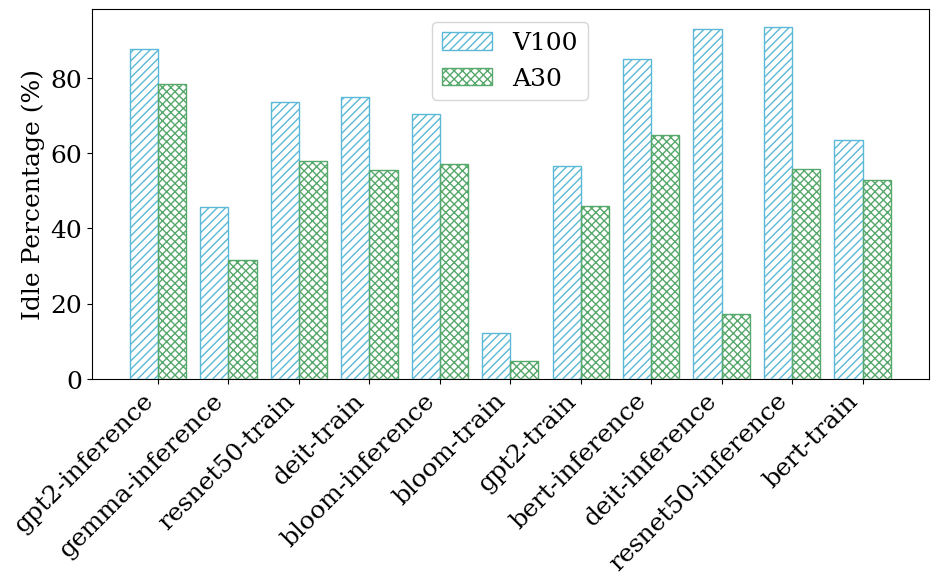

In [12]:
v100_data = final_df.select(
    pl.col("benchmark"),
    pl.lit("V100").alias("device"),
    ((pl.col("v100_measured_total_time_us") - pl.col("v100_measured_kernel_time_sum_us"))  * 100 / pl.col("v100_measured_total_time_us")).alias("modeled_idle_pct"),
    pl.col("v100_measured_idle_time_us").alias("measured_idle_us")
)

a30_data = final_df.select(
    pl.col("benchmark"),
    pl.lit("A30").alias("device"),
    ((pl.col("a30_measured_total_time_us") - pl.col("a30_measured_kernel_time_sum_us")) * 100 / pl.col("a30_measured_total_time_us")).alias("modeled_idle_pct"),
    pl.col("a30_measured_idle_time_us").alias("measured_idle_us")
)

plot_df = pl.concat([v100_data, a30_data])

ax = plot_bar(
    plot_df, 
    x="benchmark", 
    y="modeled_idle_pct", 
    hue="device", 
    ndigits=0
)

ax.set_ylabel("Idle Percentage (%)")